<a href="https://colab.research.google.com/github/Ridzzz0Alam/Data_Science/blob/main/Assignment_on_module_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Reading the data file in df

**Read the csv data file and disply its head**

In [2]:
# Code here please
df = pd.read_csv('mammographic_masses_data_clean.csv')
df.head()

,BI-RADS,Age,Shape,Margin,Density,Target
0,5,67,3,5,3,1
1,5,58,4,5,3,1
2,4,28,1,1,3,0
3,5,57,1,5,3,1
4,5,76,1,4,3,1


,BI-RADS,Age,Shape,Margin,Density,Target
0,5,67,3,5,3,1
1,5,58,4,5,3,1
2,4,28,1,1,3,0
3,5,57,1,5,3,1
4,5,76,1,4,3,1


**How many data entries you have?**

In [4]:
# Code here please
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   BI-RADS  830 non-null    int64
 1   Age      830 non-null    int64
 2   Shape    830 non-null    int64
 3   Margin   830 non-null    int64
 4   Density  830 non-null    int64
 5   Target   830 non-null    int64
dtypes: int64(6)
memory usage: 39.0 KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 6 columns):
BI-RADS    830 non-null int64
Age        830 non-null int64
Shape      830 non-null int64
Margin     830 non-null int64
Density    830 non-null int64
Target     830 non-null int64
dtypes: int64(6)
memory usage: 39.0 KB


**Which type of cancer is common?**

In [5]:
# Code here please
df['Target'].value_counts()

,count
Target,
0,427
1,403


0    427
1    403
Name: Target, dtype: int64

**Reproduce the output to show some statistics**

In [6]:
# Code here please
df.describe()

,BI-RADS,Age,Shape,Margin,Density,Target
count,830.000000,830.000000,830.000000,830.000000,830.000000,830.000000
mean,4.393976,55.781928,2.781928,2.813253,2.915663,0.485542
std,1.888371,14.671782,1.242361,1.567175,0.350936,0.500092
min,0.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,46.000000,2.000000,1.000000,3.000000,0.000000
50%,4.000000,57.000000,3.000000,3.000000,3.000000,0.000000
75%,5.000000,66.000000,4.000000,4.000000,3.000000,1.000000
max,55.000000,96.000000,4.000000,5.000000,4.000000,1.000000


,BI-RADS,Age,Shape,Margin,Density,Target
count,830.000000,830.000000,830.000000,830.000000,830.000000,830.000000
mean,4.393976,55.781928,2.781928,2.813253,2.915663,0.485542
std,1.888371,14.671782,1.242361,1.567175,0.350936,0.500092
min,0.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,46.000000,2.000000,1.000000,3.000000,0.000000
50%,4.000000,57.000000,3.000000,3.000000,3.000000,0.000000
75%,5.000000,66.000000,4.000000,4.000000,3.000000,1.000000
max,55.000000,96.000000,4.000000,5.000000,4.000000,1.000000


** Do the Train Test Split** using test size 0.3

In [7]:
# Code here please
from sklearn.model_selection import train_test_split

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 581
Test set size: 249


### Decision Tree
**Importing decision tree classifier and create its instance**

In [8]:
# Code here please
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
print(dtree)

DecisionTreeClassifier()


**Fit the training data to the model**

In [9]:
# Code here please
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_split=1e-07, min_samples_leaf=1,
            min_samples_split=2, min_weight_fraction_leaf=0.0,
            presort=False, random_state=None, splitter='best')

**What is the Score of the model?**

Model Accuracy Score: 0.7510 (75.10%)

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.74      0.78      0.76       127
Malignant (1)       0.76      0.72      0.74       122

     accuracy                           0.75       249
    macro avg       0.75      0.75      0.75       249
 weighted avg       0.75      0.75      0.75       249

--- Confusion Matrix ---
[[99 28]
 [34 88]]


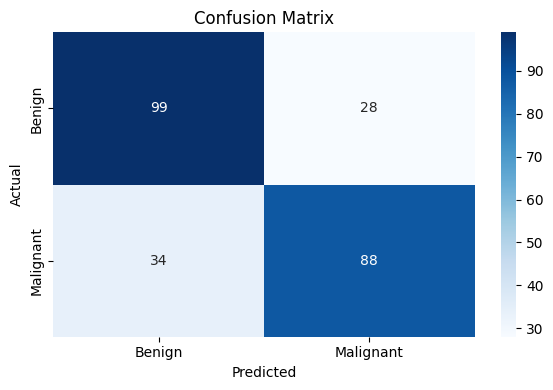

In [10]:
# Code here please
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

predictions = dtree.predict(X_test)

score = dtree.score(X_test, y_test)
print(f'Model Accuracy Score: {score:.4f} ({score*100:.2f}%)')

print('\n--- Classification Report ---')
print(classification_report(y_test, predictions, target_names=['Benign (0)', 'Malignant (1)']))

print('--- Confusion Matrix ---')
cm = confusion_matrix(y_test, predictions)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()